**UE 4268 (Information et calculs quantiques)- Examen 2024**

**`Noms et prenoms`**, `matricule` et `email` 

Department of Physics - Faculty of Science - University of Yaoundé I

`Nom du Laboratoire`

`Date`

## Questions

**Cet exercice se traite exclusivement sur la feuille de composition**

1. Which of the following terms is neglected in the BO approximation?

    A.	Electronic kinetic energy operator.

    B.	Nuclear kinetic energy operator.

    C.	Potential energy between the electrons and nuclei. It is the sum of all electron-nucleus Coulomb interactions.

    D.	Potential energy operator arising from electron-electron Coulomb repulsions.
    
2. The Slater determinant state function is antisymmetric with respect to: 

    A.	the exchange of two electrons (permutation of two rows) or, 

    B.	with respect to the exchange of two spin orbitals (permutation of two columns)

    C.	Or both the above?

3. Name three fermion to qubit transformations currently supported by Qiskit Nature.

4. Name two fermion to qubit transformations that simulates a system of electrons with the same number of qubits as electrons.

5.	For which transformation does the resulting Hamiltonian commute with the number spin up and number spin down operators which can be used to taper off two qubits?


# Calcul l'état fondamental de la molécule de Cisplatin

Le **cisplatine**, cis-[Pt(NH3)2Cl2] (les deux atomes de chlore se trouvent du même côté du plan formé par le platine et les deux molécules d'ammoniac), est un médicament de chimiothérapie utilisé dans le traitement du cancer. Il possède également un stéréoisomère, le **transplatine** , trans-[Pt(NH3)2Cl2] (les deux atomes de chlore se trouvent sur des côtés opposés du plan formé par le platine et les deux molécules d'ammoniac), qui n'est pas efficace dans le traitement du cancer. En effet, le cisplatine est capable de former des liaisons croisées (adduits) avec l'ADN, perturbant la division cellulaire et induisant la mort des cellules cancéreuses.

Les structures geometriques initiales de ces deux molécules sont: './cisplatin.xyz' et './transplatin.xyz'. 

D'un point de vue énergétique, laquelle des configurations, cis ou trans, est la plus stable ?

In [1]:
try:
    import pyscf
except:
    %pip install pyscf -U
    import pyscf

pyscf.__version__

'2.5.0'

In [2]:
try :
    import py3Dmol
except:
    %pip install py3Dmol
    import py3Dmol
    
py3Dmol.__version__

'2.1.0'

In [3]:
try:
  import xtb, crest
except:
  %pip install xtb crest -U
  import xtb, crest

!xtb --version

      -----------------------------------------------------------      
     |                   =====================                   |     
     |                           x T B                           |     
     |                   =====================                   |     
     |                         S. Grimme                         |     
     |          Mulliken Center for Theoretical Chemistry        |     
     |                    University of Bonn                     |     
      -----------------------------------------------------------      

   * xtb version 6.6.1 (8d0f1dd) compiled by 'conda@1efc2f54142f' on 2023-08-01

normal termination of xtb


In [4]:
!crest --version


       |                                            |
       |                 C R E S T                  |
       |                                            |
       |  Conformer-Rotamer Ensemble Sampling Tool  |
       |          based on the GFN methods          |
       |             P.Pracht, S.Grimme             |
       |          Universitaet Bonn, MCTC           |
       Version 2.12,   Thu 19. Mai 16:32:32 CEST 2022
  Using the xTB program. Compatible with xTB version 6.4.0

   Cite work conducted with this code as

   • P.Pracht, F.Bohle, S.Grimme, PCCP, 2020, 22, 7169-7192.
   • S.Grimme, JCTC, 2019, 15, 2847-2862.

   and for works involving QCG as

   • S.Spicher, C.Plett, P.Pracht, A.Hansen, S.Grimme,
     JCTC, 2022, 18 (5), 3174-3189.

   with help from:
   C.Bannwarth, F.Bohle, S.Ehlert, S.Grimme,
   C.Plett, P.Pracht, S.Spicher

   This program is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without even the implied warranty of
   M

In [5]:
try:
    import rdkit
except:
    %pip install rdkit -U
    import rdkit

rdkit.__version__

'2023.09.6'

In [6]:
try:
    import qiskit_nature
except:
    %pip install qiskit-nature[pyscf] -U
    import qiskit_nature
    
qiskit_nature.__version__

'0.7.2'

### Calculs semi-empiriques avec xTB

On va utiliser le programme **xTB** pour repondre à cette question.

1. Donner une représentation 3D des deux molécules en utilisant l'application `Py3Dmol`. On utilisera `viewer = py3Dmol.view(viewergrid=(1, 2), width=300*2, height=250, linked=True)` afin que les deux structures apparaissent cote-à-cote. On utilisera aussi, `open('fichier.xyz').read()`.


In [7]:
"""_3D representation with py3Dmol
"""
# Create a py3Dmol.view object
viewer = py3Dmol.view(viewergrid=(1, 2), width=300*2, height=250, linked=False)

# Add the molecule model to the view
cis_xyz = open('cisplatin.xyz').read()
viewer.addModel(cis_xyz,'xyz', viewer=(0, 0))

trans_xyz = open('transplatin.xyz').read()
viewer.addModel(trans_xyz,'xyz', viewer=(0, 1))

# Set the style of representation
viewer.setStyle({'stick': {}, 'sphere': {'scale': 0.30}})
viewer.setViewStyle({"style": "outline", "width": 0.05})

# Add legends for each molecule
viewer.addLabel('Cisplatin', {'position': {'x': -2, 'y': -3.5, 'z': 0}}, viewer=(0, 0))
viewer.addLabel('Transplatin', {'position': {'x': -2, 'y': -3.5, 'z': 0}}, viewer=(0, 1))

# Zoom to fit the molecule in the view
viewer.zoomTo()

# Show the molecule view
viewer.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

2. Afin d'amener cahque molécule vers un minimum (local) de la surface d'énergie potentielle (PES), on va optimiser les géométries des cisplatin et transplatin avec xTB. On utilisera l'option `tight` pour indiquer le critère de convergence. Procédure:

* pré-optimisation avec xTB avec pour fichiers de sortie `cisplatin_xtb1.out` et `transplatin_xtb1.out`;
* choix de la meilleure conformation avec CREST;
* optimisation de la meilleur comformation avec xTB avec pour fichier de sortie `cisplatin_xtb2.out`  et `transplatin_xtb2.out`.

In [8]:
%%bash
# Pré-optimisation avec xTB
xtb cisplatin.xyz --gfn 2 --opt tight --parallel 2 > cisplatin_xtb1.out

# Best conformation search with CREST
crest xtbopt.xyz -gff -mquick --noreftopo

# xTB geometry optimization of the crest best conformation
xtb crest_best.xyz --gfn 2 --opt tight --parallel 2 > cisplatin_xtb2.out

#Copied the optimization structure 'xtbopt.xyz' to 'cis_xtb.xyz'
cp 'xtbopt.xyz' 'cis_xtb.xyz'

normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL



       |                                            |
       |                 C R E S T                  |
       |                                            |
       |  Conformer-Rotamer Ensemble Sampling Tool  |
       |          based on the GFN methods          |
       |             P.Pracht, S.Grimme             |
       |          Universitaet Bonn, MCTC           |
       Version 2.12,   Thu 19. Mai 16:32:32 CEST 2022
  Using the xTB program. Compatible with xTB version 6.4.0

   Cite work conducted with this code as

   • P.Pracht, F.Bohle, S.Grimme, PCCP, 2020, 22, 7169-7192.
   • S.Grimme, JCTC, 2019, 15, 2847-2862.

   and for works involving QCG as

   • S.Spicher, C.Plett, P.Pracht, A.Hansen, S.Grimme,
     JCTC, 2022, 18 (5), 3174-3189.

   with help from:
   C.Bannwarth, F.Bohle, S.Ehlert, S.Grimme,
   C.Plett, P.Pracht, S.Spicher

   This program is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without even the implied warranty of
   M

normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL


Pour la molécule cisplatin,
* la distance Pt-Cl et Pt-N optimisées sont respectivement $2.3025\AA$ et $2.0462\AA$;
* l'énergie totale est $-22.618686779678\rm{Ha}$;
* le nombre d'itérations ayant conduit à la convergence $27$.

In [10]:
# Deleted various TB files before the next optimization calculations
import subprocess as sp

sp.run(['rm', 'bondlengths', 'charges', 'coord', 'coord.original', 'cregen_0.tmp', 'cregen_1.tmp', 'xtbopt2.out',
        'cre_members', 'crest_best.xyz', 'crest_conformers.xyz', 'crest.energies', 'crest_rotamers.xyz', 
        'gfnff_charges', 'gfnff_topo', '.history.xyz', 'struc.xyz', 'wbo','xtbopt.xyz', 'xtbopt.log', '.xtboptok', 
        'xtbrestart', 'xtbtopo.mol', 'xtblast.xyz', 'gfnff_adjacency'], stdout=sp.DEVNULL, stderr=sp.DEVNULL)

CompletedProcess(args=['rm', 'bondlengths', 'charges', 'coord', 'coord.original', 'cregen_0.tmp', 'cregen_1.tmp', 'xtbopt2.out', 'cre_members', 'crest_best.xyz', 'crest_conformers.xyz', 'crest.energies', 'crest_rotamers.xyz', 'gfnff_charges', 'gfnff_topo', '.history.xyz', 'struc.xyz', 'wbo', 'xtbopt.xyz', 'xtbopt.log', '.xtboptok', 'xtbrestart', 'xtbtopo.mol', 'xtblast.xyz', 'gfnff_adjacency'], returncode=1)

In [11]:
%%bash
# Pre-optimisation with xTB
xtb transplatin.xyz --gfn 2 --opt tight --parallel 2 > transplatin_xtb1.out

# Best conformation search with CREST
crest xtbopt.xyz -gff -mquick --noreftopo

# xTB geometry optimization of the crest best conformation
xtb crest_best.xyz --gfn 2 --opt tight --parallel 2 > transplatin_xtb2.out

normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL



       |                                            |
       |                 C R E S T                  |
       |                                            |
       |  Conformer-Rotamer Ensemble Sampling Tool  |
       |          based on the GFN methods          |
       |             P.Pracht, S.Grimme             |
       |          Universitaet Bonn, MCTC           |
       Version 2.12,   Thu 19. Mai 16:32:32 CEST 2022
  Using the xTB program. Compatible with xTB version 6.4.0

   Cite work conducted with this code as

   • P.Pracht, F.Bohle, S.Grimme, PCCP, 2020, 22, 7169-7192.
   • S.Grimme, JCTC, 2019, 15, 2847-2862.

   and for works involving QCG as

   • S.Spicher, C.Plett, P.Pracht, A.Hansen, S.Grimme,
     JCTC, 2022, 18 (5), 3174-3189.

   with help from:
   C.Bannwarth, F.Bohle, S.Ehlert, S.Grimme,
   C.Plett, P.Pracht, S.Spicher

   This program is distributed in the hope that it will be useful,
   but WITHOUT ANY WARRANTY; without even the implied warranty of
   M

normal termination of xtb
Note: The following floating-point exceptions are signalling: IEEE_UNDERFLOW_FLAG IEEE_DENORMAL


In [12]:
#Copied the optimization structure 'xtbopt.xyz' to 'trans_xtb.xyz'
!cp 'xtbopt.xyz' 'trans_xtb.xyz'

Pour la molécule transplatin,
* la distance Pt-Cl et Pt-N optimisées sont respectivement $2.3025\AA$ et $2.0463\AA$;
* l'énergie totale est $-22.618686931946\rm{Ha}$;
* le nombre d'itérations ayant conduit à la convergence $27$.

3. Calculer la RMSD (Root Mean Square Deviation) pour évaluer l'alignement optimal (RMSD minimum) des deux structures optimisées en utilisant `rdkit.Chem.AllChem.AlignMol`. 

In [13]:
# Calculate the RMSD to evaluate the optimally (minimum RMSD) alignment of mol_rdkit1  with mol_xtb
from rdkit import Chem
from rdkit.Chem import AllChem 

mol1 = Chem.MolFromXYZFile('cis_xtb.xyz')
mol2 = Chem.MolFromXYZFile('trans_xtb.xyz')
AllChem.AlignMol(mol1, mol2)

2.1298909270541175

Une RMSD de $2.0969\AA$ entre les deux structures moléculaires cis et trans indique une forte similarité structurale globale, avec des différences locales potentielles indiquant des variations conformationnelles à considérer.

4. Evaluer, en kcal/mol la différence des énergies totales xTB du cisplatine et du transplatine, sachant que le facteur de conversion de Hartree en kcal/mol est au2kcal = 627.509474. Commenter par rapport au resultat de [Liu et Franke](https://doi.org/10.1002/jcc.10030).

In [14]:
au2kcal = 627.509474
Erel = (-22.618686779678 - (-22.618686931946)) * au2kcal
Erel

9.554961313594946e-05

Cette valeur largement en dessous de la précision chimique, est en cohérence avec la faible RMSD. Comparée à la valeur de Liu et Franke, on peut estimer que le résultat obtenu avec xtb est en bon accord qualitatif ou semi-quantitatif avec le résultat obtenu avec le haut niveau de théorie. Avec xtb, nous avons pu obtenir ce résultat semi-quantitatif en quelques secondes.

In [15]:
# Deleted various TB files before the next calculations
import subprocess as sp

sp.run(['rm', 'bondlengths', 'charges', 'coord', 'coord.original', 'cregen_0.tmp', 'cregen_1.tmp', 'xtbopt2.out',
        'cre_members', 'crest_best.xyz', 'crest_conformers.xyz', 'crest.energies', 'crest_rotamers.xyz', 
        'gfnff_charges', 'gfnff_topo', '.history.xyz', 'struc.xyz', 'wbo','xtbopt.xyz', 'xtbopt.log', '.xtboptok', 
        'xtbrestart', 'xtbtopo.mol', 'xtblast.xyz', 'gfnff_adjacency'], stdout=sp.DEVNULL, stderr=sp.DEVNULL)

CompletedProcess(args=['rm', 'bondlengths', 'charges', 'coord', 'coord.original', 'cregen_0.tmp', 'cregen_1.tmp', 'xtbopt2.out', 'cre_members', 'crest_best.xyz', 'crest_conformers.xyz', 'crest.energies', 'crest_rotamers.xyz', 'gfnff_charges', 'gfnff_topo', '.history.xyz', 'struc.xyz', 'wbo', 'xtbopt.xyz', 'xtbopt.log', '.xtboptok', 'xtbrestart', 'xtbtopo.mol', 'xtblast.xyz', 'gfnff_adjacency'], returncode=1)

### Calculs DFT

Afin de minimiser les resources computationnelles, on va utiliser 
*  `qiskit_nature.second_q.drivers.PySCFDriver` (qui sera utile pour la partie quantum computing);
* les structures xyz optimisée précédemment avec `xTB`, cad, `cis_xtb.xyz` et `trans_xtb.xyz`; 
* l'ensemble de base `def2-SVP` et la fonctionnelle d'echange hybride `PBE0`.


In [16]:
from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import MethodType, PySCFDriver

cis_driver = PySCFDriver(
    atom=open('cis_xtb.xyz').read().strip().split('\n')[2:],# Remove the first two lines from XYZ data
    basis='def2-SVP',
    charge=0,
    spin=0,
    method=MethodType.RKS,
    xc_functional="PBE0",
    xcf_library="xcfun",
    unit=DistanceUnit.ANGSTROM,
)

cis_driver.run_pyscf()
mf_cis = cis_driver._calc

1. Déduire, pour la molécule cisplatin (optimisée avec `xTB`) les propriétés du niveau de Fermi, cad, les index du HOMO et LUMO, et l'énergie du gap HOMO-LUMO en eV. 

In [17]:
from pyscf.data import nist
au2ev = nist.HARTREE2EV

In [18]:
cis_lumo_idx = mf_cis.mo_occ.tolist().index(0.)
cis_homo_idx = cis_lumo_idx - 1
print('For cisplatin')
print(f"HOMO and LUMO index are (Fermi level) {cis_homo_idx, cis_lumo_idx}")
print(f'HOMO energy  = {mf_cis.mo_energy[cis_homo_idx] * au2ev} eV')
print(f'LUMO energy = {mf_cis.mo_energy[cis_lumo_idx] * au2ev} eV')
print(f'HOMO-LUMO gap = {abs(mf_cis.mo_energy[cis_homo_idx] - mf_cis.mo_energy[cis_lumo_idx]) * au2ev} eV')

For cisplatin
HOMO and LUMO index are (Fermi level) (65, 66)
HOMO energy  = -4.567476198797383 eV
LUMO energy = -2.8523200938498676 eV
HOMO-LUMO gap = 1.715156104947516 eV


2. Indiquer, en reprenant le calcul précédent pour la molécule transplatin (optimisée avec `xTB`) les propriétés du niveau de Fermi, cad, les index du HOMO et LUMO, et l'énergie du gap HOMO-LUMO en eV. 

In [19]:
trans_driver = PySCFDriver(
    atom=open('trans_xtb.xyz').read().strip().split('\n')[2:],# Remove the first two lines from XYZ data
    basis='def2-SVP',
    charge=0,
    spin=0,
    method=MethodType.RKS,
    xc_functional="PBE0",
    xcf_library="xcfun",
    unit=DistanceUnit.ANGSTROM,
)

trans_driver.run_pyscf()
mf_trans = trans_driver._calc

trans_lumo_idx = mf_trans.mo_occ.tolist().index(0.)
trans_homo_idx = trans_lumo_idx - 1

print('For transplatin')
print(f"HOMO and LUMO index are (Fermi level) {trans_homo_idx, trans_lumo_idx}")
print(f'HOMO energy  = {mf_trans.mo_energy[trans_homo_idx] * au2ev} eV')
print(f'LUMO energy = {mf_trans.mo_energy[trans_lumo_idx] * au2ev} eV')
print(f'HOMO-LUMO gap = {abs(mf_trans.mo_energy[trans_homo_idx] - mf_trans.mo_energy[trans_lumo_idx]) * au2ev} eV')

For transplatin
HOMO and LUMO index are (Fermi level) (65, 66)
HOMO energy  = -4.563461836901042 eV
LUMO energy = -2.8449668379445034 eV
HOMO-LUMO gap = 1.7184949989565388 eV


In [30]:
mf_cis.dump_scf_summary()

**** SCF Summaries ****
Total Energy =                       -3999.429256780666037
Nuclear Repulsion Energy =            1171.049971892003668
One-electron Energy =                -7771.087154415363329
Two-electron Coulomb Energy =         2725.093309050229436
DFT Exchange-Correlation Energy =     -124.485383307536438


In [31]:
mf_trans.dump_scf_summary()

**** SCF Summaries ****
Total Energy =                       -3999.424548011178103
Nuclear Repulsion Energy =            1170.930202791325883
One-electron Energy =                -7770.842988346382299
Two-electron Coulomb Energy =         2724.972676132082597
DFT Exchange-Correlation Energy =     -124.484438588204284


3. Evaluer, en kcal/mol la différence des énergies totales DFT du cisplatine et du transplatine. Commenter par rapport au resultat de [Liu et Franke](https://doi.org/10.1002/jcc.10030).

In [20]:
Erel2 = (mf_cis.e_tot - mf_trans.e_tot) * au2kcal
Erel2

-2.954797464560557

On note qu'il y a moins de 4 kcal/mole de difference avec le résultat de Liu et Franke, malgré le fait que nous avons une combinaison PBE0/def2-SVP qui n'est pas reputée très précise.

### Espace actif et calculs quantique

Dans cette partie, on s'interesse seulement à la molecule cisplatin. L'energie de l'état fondamental est déterminée à partir d'un solveur VQE dont les trois éléments essentiels sont :
* Une **forme variationnelle ou *ansatz***. Nous utilisons ici l'*ansatz* Unitary Coupled Cluster (UCC). La valeur par défaut est d'utiliser toutes les excitations simples et doubles. Cependant, le type d'excitation (S, D, SD) ainsi que d'autres paramètres peuvent être sélectionnés. La forme variationnelle `qiskit_nature.second_q.circuit.library.UCCSD` est préparée avec un état initial `qiskit_nature.second_q.circuit.library.HartreeFock`, qui initialise l'occupation de nos qubits en fonction du problème que nous essayons de résoudre.
* Une primitive, qui sera ici `qiskit.primitives.Estimator` pour le calcul des valeurs moyennes;
* Un optimiseur classique (`qiskit_algorithms.optimizers.SPSA`). 

1. A partir de `ElectronicStructureProblem` (qu'on obtient de `cis_driver.run()`), déterminer le nombre de particules (`num_particles`) et le nombre d'orbitales spatiales (`num_spatial_orbitals`). Ce dernier correspond au nombre totales d'orbitales actives (`active_orbitals`). Commenter.

In [21]:
cis_problem = cis_driver.run()

In [22]:
print(cis_problem.num_particles)
print(cis_problem.num_spatial_orbitals)

(66, 66)
126


Un espace de 126 orbitales actives nécessite au moins 126*2=252 qubits, ce que ne peut supporter un calcul NISQ actuellement. Il nous faut alors définir un espace actif raisonnable.

2. Utiliser 
* `qiskit_nature.second_q.transformers.ActiveSpaceTransformer` pour définir un espace active `ActiveSpaceTransformer(num_electrons=2, num_spatial_orbitals=2)`. 
* `qiskit_nature.second_q.mappers.ParityMapper` et `qiskit_nature.second_q.mappers.TaperedQubitMapper` pour obtenir le Hamiltonien qubit avec la réduction $\mathbb{Z}_2$.
* Imprimer cet Hamiltonien.

In [23]:
# Reduced Hamiltonian
from qiskit_nature.second_q.transformers import ActiveSpaceTransformer
from qiskit_nature.second_q.mappers import ParityMapper, TaperedQubitMapper

as_transformer = ActiveSpaceTransformer(2, 2)
cis_as_problem = as_transformer.transform(cis_problem)

mapper = ParityMapper(num_particles=cis_as_problem.num_particles)
mapper = cis_as_problem.get_tapered_mapper(mapper)

Hamil_z2qubit = mapper.map(cis_as_problem.hamiltonian.second_q_op())

print(f"Number of items in the PM Z2 Pauli list:", len(Hamil_z2qubit))
print(Hamil_z2qubit)


Number of items in the PM Z2 Pauli list: 9
SparsePauliOp(['II', 'IZ', 'IX', 'ZI', 'XI', 'ZZ', 'XZ', 'ZX', 'XX'],
              coeffs=[-0.42688928+0.j,  0.0317393 +0.j, -0.00048046+0.j, -0.0317393 +0.j,
 -0.00048046+0.j, -0.01453668+0.j, -0.00070578+0.j,  0.00070578+0.j,
  0.0165363 +0.j])


3. Définir l'état initial Hartree-Fock de la forme variationnelle ou *Ansatz*. Visualiser cet état.


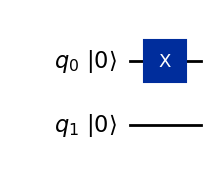

In [24]:
# Initial state
from qiskit_nature.second_q.circuit.library import HartreeFock

HF_state = HartreeFock(cis_as_problem.num_spatial_orbitals, cis_as_problem.num_particles, mapper)
HF_state.draw('mpl',initial_state=True)

4. Construire le solveur VQE et calculer l'état fondamental de la molécule grâce à la classe `qiskit_nature.second_q.algorithms.GroundStateEigensolver`.

In [25]:
# Setup solver
from qiskit_nature.second_q.circuit.library import UCCSD
from qiskit.primitives import Estimator
from qiskit_algorithms.optimizers import SPSA
from qiskit_algorithms import VQE
from qiskit_nature.second_q.algorithms import GroundStateEigensolver

import numpy as np

ansatz = UCCSD(
    cis_as_problem.num_spatial_orbitals,
    cis_as_problem.num_particles,
    mapper,
    initial_state = HF_state)

vqe_solver = VQE(Estimator(), ansatz, SPSA())
vqe_solver.initial_point = np.zeros(ansatz.num_parameters) # Initialisation with zero-qubit

# VQE results
GS_VQE = GroundStateEigensolver(mapper, vqe_solver)
GS_VQE_res = GS_VQE.solve(cis_as_problem)

print(f'Total VQE GS energy = {GS_VQE_res.total_energies[0]} a.u.')



Total VQE GS energy = -3992.443034153004 a.u.


5. Le solveur purement classique `qiskit_algorithms.NumPyMinimumEigensolver` est l'algorithme diagonise exactement l'Hamiltonien. Il peut-être considéré comme équivalent à la méthode Full Configuration Interaction (FCI) et peut donc être utilisé sur de petits systèmes pour vérifier les résultats des algorithmes quantiques. EStimer en kcal/mol l'écart entre le resultat FCI ou Numpy et celui du solveur VQE et commenter´

In [26]:
# Numpy/FCI Results 
from qiskit_algorithms import NumPyMinimumEigensolver

numpy_solver = NumPyMinimumEigensolver()
NP_calc = GroundStateEigensolver(mapper, numpy_solver)
GS_NP_res = NP_calc.solve(cis_as_problem)

print(f'Total Numpy GS energy = {GS_NP_res.total_energies[0]} a.u.')

Total Numpy GS energy = -3992.4431855628127 a.u.


In [27]:
DE = GS_NP_res.total_energies[0] - GS_VQE_res.total_energies[0]
print(f'The difference between Numpy and VQE GS energy = {DE * au2kcal} kcal/mol')


The difference between Numpy and VQE GS energy = -0.09501108928737223 kcal/mol


La différence d'énergie étant inférieure à la précision chimique (1kcal/mol), le calcul VQE est quasiment indentique au calcul FCI.